# Step 2 — Chunking: Build the RAG Document Database

This notebook assembles all text chunks that will go into the FAISS retrieval index.
It outputs a single `chunks/chunks.csv` file consumed by the next notebook (`rag_step3_index.ipynb`).

**Sources combined here:**
- IHC training examples (loaded from HuggingFace, `post` column)
- ISHate training examples (loaded from HuggingFace, `text` column)
- External documents: deferred (see section 5)

**Output CSV schema:**
```
chunk_id | text
---------|-------------------------------
0        | [hate] you are all subhuman
1        | [not hate] I love this city
```

The label is baked into the `text` field so retrieved chunks can be used directly in few-shot prompts at inference time.

## 1. Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from transformers import AutoTokenizer

## 2. Load IHC Training Data

Dataset: `tasksource/implicit-hate-stg1`  
Text column: `post`  
Label column: `class` → `not_hate` maps to `not_hate`, everything else maps to `hate`

Only the **training split** is used (90/10 split with seed=42, same as baseline_step1).  
The test split is reserved for inference queries only.  
Labels are kept as a local field for deduplication analysis — not written to the output CSV.

In [ ]:
# Full dataset from the IHC, lines are an entry, columns are a feature like post (the text), class (hate/non-hate), ...
ihc_ds = load_dataset("tasksource/implicit-hate-stg1", split="train")
print("Length of the full dataset : ", len(ihc_ds))
# Reproduce the same 90/10 split as baseline_step1 (seed=42) to ensure
ihc_train = ihc_ds.train_test_split(test_size=0.10, seed=42)["train"]
print("Length of the training dataset : ", len(ihc_train))

# Creating the dataset to be chunked, converting the same time implicit/explicite hate into hate because our models will focus on binary classification
ihc_chunks = []
for row in ihc_train:
    label = "not_hate" if row["class"] == "not_hate" else "hate"
    ihc_chunks.append({"source": "ihc_train", "text": row["post"], "label": label})

print(f"IHC training examples: {len(ihc_chunks)}")
print("Examples of the data we have")
for i in range(5):
    print(ihc_chunks[i+5])

Found cached dataset csv (/Users/pierrebernadet/.cache/huggingface/datasets/tasksource___csv/tasksource--implicit-hate-stg1-49d83545bb13cb1d/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1)
Loading cached split indices for dataset at /Users/pierrebernadet/.cache/huggingface/datasets/tasksource___csv/tasksource--implicit-hate-stg1-49d83545bb13cb1d/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1/cache-76b7c621accc1eba.arrow and /Users/pierrebernadet/.cache/huggingface/datasets/tasksource___csv/tasksource--implicit-hate-stg1-49d83545bb13cb1d/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1/cache-a43519a0b02ab0be.arrow


Length of the full dataset :  21480
Length of the training dataset :  19332
IHC training examples: 19332
Examples of the data we have
{'source': 'ihc_train', 'text': '. help biafrans get freedom and independence . please save biafrans from murderous nigeria terrorists', 'label': 'hate'}
{'source': 'ihc_train', 'text': 'you should dead  racist  motherfuckersthis is ku klux klan', 'label': 'hate'}
{'source': 'ihc_train', 'text': "we're all vertebrates too . except for cucks .", 'label': 'hate'}
{'source': 'ihc_train', 'text': 'white people are not alowed to have opinions if we do we are so bad', 'label': 'not_hate'}
{'source': 'ihc_train', 'text': "how the dynasty turned large chunks of lutyens ' delhi into private property", 'label': 'not_hate'}


## 3. Load ISHate Training Data

Dataset: `BenjaminOcampo/ISHate`  
Text column: `text`  
Label column: `hateful_layer` → `Non-HS` maps to `not_hate`, everything else maps to `hate`

Uses the pre-made train split directly — no manual split needed.

In [5]:
# Same way of loading the data but with different tools
# Load directly only the training data via ishate_train.parquet.gzip
ishate_path = hf_hub_download(repo_id="BenjaminOcampo/ISHate", filename="ishate_train.parquet.gzip", repo_type="dataset")
ishate_df = pd.read_parquet(ishate_path)
print("Length of the training dataset : ", len(ishate_df))

ishate_chunks = []
for _, row in ishate_df.iterrows():
    label = "not_hate" if row["hateful_layer"] == "Non-HS" else "hate"
    ishate_chunks.append({"source": "ishate_train", "text": row["text"], "label": label})

print(f"ISHate training examples: {len(ishate_chunks)}")
print("Examples of the data we have")
for i in range(5):
    print(ishate_chunks[i+5])

Length of the training dataset :  55023
ISHate training examples: 55023
Examples of the data we have
{'source': 'ishate_train', 'text': "fuk that I burned a qu'ran and pissed on it...", 'label': 'hate'}
{'source': 'ishate_train', 'text': 'You left me in the dark for some bitch that had a kid while you were in the pin but yet you still chose that dry cunt over your son how sad.', 'label': 'not_hate'}
{'source': 'ishate_train', 'text': 'An Illegal Alien took his own life because he decide he would break into the U.S Steal IDs and SSN to Work Illegally Robbing the U.S instead of sending for his family he killed himself Really didnt care about his Family huh ? #SendthemBack #Immigration', 'label': 'hate'}
{'source': 'ishate_train', 'text': '@MailOnline Bloody Germany who needs Germany we dont want their Visa plans were are fed up of being over ran by migrants no Uk Jobs threaten', 'label': 'hate'}
{'source': 'ishate_train', 'text': 'Immigrants are not welcome here, and should not mix with 

## 4. Deduplication

Normalization: lowercase + strip whitespace.

### 4a — Analysis
Check for duplicate entries within each dataset and across both datasets.

In [11]:
# Convert both datasets into panda's DataFrames to have panda's methods we need for deduplication analysis
tmp_ihc = pd.DataFrame(ihc_chunks)
tmp_ishate = pd.DataFrame(ishate_chunks)

# Create a normalized column for duplicate detection: lowercase + strip whitespace
tmp_ihc["norm"] = tmp_ihc["text"].str.lower().str.strip()
tmp_ishate["norm"] = tmp_ishate["text"].str.lower().str.strip()

# We can see with these prints that the normalization is effective, some text has uppercases or spaces in the beggining of the tweets
print("Examples of data with the new row 'norm'")
print("IHC:")
for i in range(3):
    print(tmp_ihc.iloc[i+10])
print("ISHate:")
for i in range(3):
    print(tmp_ishate.iloc[i+10])

# Find duplicates within IHC
# Use the function duplicated from panda to set to true every row duplicated in the column "norm" and false to the ones not duplicated
ihc_dupe_mask = tmp_ihc.duplicated(subset="norm", keep=False)
# .sum() gives the number of Trues from ihc_dupes_mask
ihc_dupes = tmp_ihc.duplicated(subset="norm").sum()
print(f"IHC internal duplicates: ", ihc_dupes)
if ihc_dupes:
    sample_norm = tmp_ihc[ihc_dupe_mask]["norm"].iloc[0]
    print(tmp_ihc[tmp_ihc["norm"] == sample_norm][["text"]].to_string(index=False))

# Find duplicates within ISHate (floowing the same process as for IHC)
ishate_dupe_mask = tmp_ishate.duplicated(subset="norm", keep=False)
ishate_dupes = tmp_ishate.duplicated(subset="norm").sum()
print(f"\nISHate internal duplicates: {ishate_dupes}")
if ishate_dupes:
    sample_norm = tmp_ishate[ishate_dupe_mask]["norm"].iloc[0]
    print(tmp_ishate[tmp_ishate["norm"] == sample_norm][["text"]].to_string(index=False))

# Find cross-datasets duplicates
# Convert each norm column to a set of unique values, then & gives the intersection (texts present in both)
overlap = set(tmp_ihc["norm"]) & set(tmp_ishate["norm"])
print(f"\nCross-dataset overlaps: {len(overlap)}")
if overlap:
    # Convert the set overlap into an iterable and take the first one arbitrarly to show one example of cross-dataset duplication
    sample_norm = next(iter(overlap))
    # Locate this example into the original datasets
    ihc_row = tmp_ihc[tmp_ihc["norm"] == sample_norm][["source", "text"]].iloc[0]
    ishate_row = tmp_ishate[tmp_ishate["norm"] == sample_norm][["source", "text"]].iloc[0]
    print(f"  IHC:    {ihc_row['text']}")
    print(f"  ISHate: {ishate_row['text']}")

Examples of data with the new row 'norm'
IHC:
source                                            ihc_train
text       so your source is the known for their white n...
label                                              not_hate
norm      so your source is the known for their white na...
Name: 10, dtype: object
source                                            ihc_train
text      and how were the alt white peaceful when they ...
label                                                  hate
norm      and how were the alt white peaceful when they ...
Name: 11, dtype: object
source                                            ihc_train
text       national review : white working class towns  ...
label                                              not_hate
norm      national review : white working class towns  "...
Name: 12, dtype: object
ISHate:
source                                         ishate_train
text      Gays are inherently evil, we cannot accept gay...
label                             

### 4b — Deduplication Solving

Drop duplicates and update `ihc_chunks` / `ishate_chunks`.  
Strategy:
- Within each dataset: keep first occurrence.
- Cross-dataset: keep IHC entry, drop the duplicate from ISHate.

In [ ]:
previous_ihc_lenght = len(ihc_chunks)
previous_ishate_lenght = len(ishate_chunks)

# Within-dataset dedup (keep first occurrence), use a panda's method
tmp_ihc_dedup = tmp_ihc.drop_duplicates(subset="norm", keep="first")
tmp_ishate_dedup = tmp_ishate.drop_duplicates(subset="norm", keep="first")

# Cross-dataset: keep IHC entry, drop duplicate from ISHate
ihc_norms = set(tmp_ihc_dedup["norm"])
# Locate every row from ISHate whose normalized text appears in the IHC dataset, flip the mask with ~, and then keep only the True results
tmp_ishate_dedup = tmp_ishate_dedup[~tmp_ishate_dedup["norm"].isin(ihc_norms)]

# Rebuild chunk lists, drop the norm column not usefull anymore, convert the DataFrame back to a list of dicts
ihc_chunks = tmp_ihc_dedup.drop(columns="norm").to_dict("records")
ishate_chunks = tmp_ishate_dedup.drop(columns="norm").to_dict("records")

print(f"IHC:    {previous_ihc_lenght:,} → {len(ihc_chunks):,}  (removed {previous_ihc_lenght - len(ihc_chunks)})")
print(f"ISHate: {previous_ishate_lenght:,} → {len(ishate_chunks):,}  (removed {previous_ishate_lenght - len(ishate_chunks)})")
print(f"Total after dedup: {len(ihc_chunks) + len(ishate_chunks):,}")

IHC:    19,332 → 19,328  (removed 4)
ISHate: 55,023 → 53,163  (removed 1860)
Total after dedup: 72,491


## 5. External Documents

**Work in progress** — External document ingestion (lexicons, typology definitions from `documents/`) will be added in a future iteration. For now only IHC and ISHate training examples are indexed.

## 6. Combine All Sources

In [ ]:
all_chunks = ihc_chunks + ishate_chunks

df = pd.DataFrame(all_chunks)
# insert the labels at the beggining of the text as [hate] or [not hate]
df["text"] = df.apply(lambda r: f"[{r['label'].replace('_', ' ')}] {r['text']}", axis=1)
# keep only the text columns to be chuncked
df = df[["text"]]
df.insert(0, "chunk_id", range(len(df)))

print(f"Total chunks: {df.shape[0]:,}")
df.head()

Total chunks: 72,491


,chunk_id,text
0,0,[not hate] we need everyone to keep winning . ...
1,1,[not hate] : the hatred spewed by robert spenc...
2,2,[not hate] are antifa boomers ?
3,3,[not hate] #trucons aren't capable of anything...
4,4,[not hate] wow you really caught that . so ha...


## 7. Token Length Analysis

The final input to the encoder at inference time will be:
`[CLS] tweet [SEP] chunk1 [SEP] chunk2 [SEP]`

With up to 3 retrieved chunks and a tweet of ~50 tokens:
`50 + 3 × chunk_length + 5 special tokens ≤ 512`

> **Note:** This budget can be revised if the number of retrieved chunks (`k`) or the typical query length changes.

### 7a — Analysis

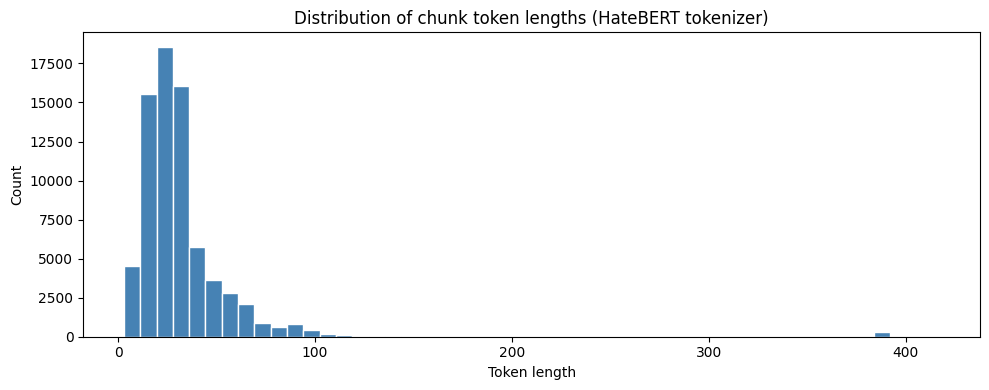

Mean:                32.1
Median:              26.0
95th percentile:     69.0
Max:                 417
Chunks > 50 tokens:  9214


In [21]:
tokenizer = AutoTokenizer.from_pretrained("GroNLP/hateBERT")

token_lengths = [len(tokenizer.encode(t, add_special_tokens=False)) for t in df["text"]]
df["token_length"] = token_lengths

plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=50, color="steelblue", edgecolor="white")
plt.xlabel("Token length")
plt.ylabel("Count")
plt.title("Distribution of chunk token lengths (HateBERT tokenizer)")
plt.tight_layout()
plt.show()

print(f"Mean:                {np.mean(token_lengths):.1f}")
print(f"Median:              {np.median(token_lengths):.1f}")
print(f"95th percentile:     {np.percentile(token_lengths, 95):.1f}")
print(f"Max:                 {max(token_lengths)}")
print(f"Chunks > 50 tokens:  {sum(l > 50 for l in token_lengths)}")

### 7b — Filtering

Remove entries with strictly more than 50 tokens. `chunk_id` is reassigned to stay contiguous.

In [22]:
MAX_TOKENS = 50

before = len(df)
df = df[df["token_length"] <= MAX_TOKENS].drop(columns="token_length").reset_index(drop=True)
df["chunk_id"] = range(len(df))

print(f"Chunks before filtering: {before:,}")
print(f"Chunks after filtering:  {len(df):,}  (removed {before - len(df)})")
df.head()

Chunks before filtering: 72,491
Chunks after filtering:  63,277  (removed 9214)


,chunk_id,text
0,0,[not hate] we need everyone to keep winning . ...
1,1,[not hate] : the hatred spewed by robert spenc...
2,2,[not hate] are antifa boomers ?
3,3,[not hate] #trucons aren't capable of anything...
4,4,[not hate] wow you really caught that . so ha...


## 8. Save

Output: `chunks/chunks.csv` — the only input needed by `rag_step3_index.ipynb`.  
Schema: `chunk_id | text`

In [23]:
os.makedirs("chunks", exist_ok=True)
df.to_csv("chunks/chunks.csv", index=False)
print(f"Saved {len(df):,} chunks to chunks/chunks.csv")

Saved 63,277 chunks to chunks/chunks.csv
